In [1]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

In [2]:
df = pd.read_csv("C:/Users/Varnika Sharma/Desktop/Crime Analysis/Crime Analysis/01_Data/Final_Dataset/cleaned_crime_data.csv")

In [3]:
selected_dataset = "All"   # Change manually for screenshots

if selected_dataset != "All":
    dff = df[df["Dataset"] == selected_dataset]
else:
    dff = df.copy()

In [4]:
import plotly.io as pio

pio.templates["purple_theme"] = pio.templates["plotly_dark"]

pio.templates["purple_theme"].layout.update(
    paper_bgcolor="#1a0b3d",   # deep purple background
    plot_bgcolor="#1a0b3d",    # card-like purple
    
    font=dict(
        family="Arial",
        size=13,
        color="#e9d5ff"
    ),
    
    title=dict(
        x=0.5,
        xanchor="center",
        font=dict(size=22, color="#f5f3ff")
    ),
    
    colorway=[
        "#a855f7",  # neon purple
        "#22d3ee",  # cyan
        "#f472b6",  # pink
        "#facc15",  # yellow
        "#4ade80",  # green
        "#fb7185"   # coral
    ]
)

pio.templates.default = "purple_theme"

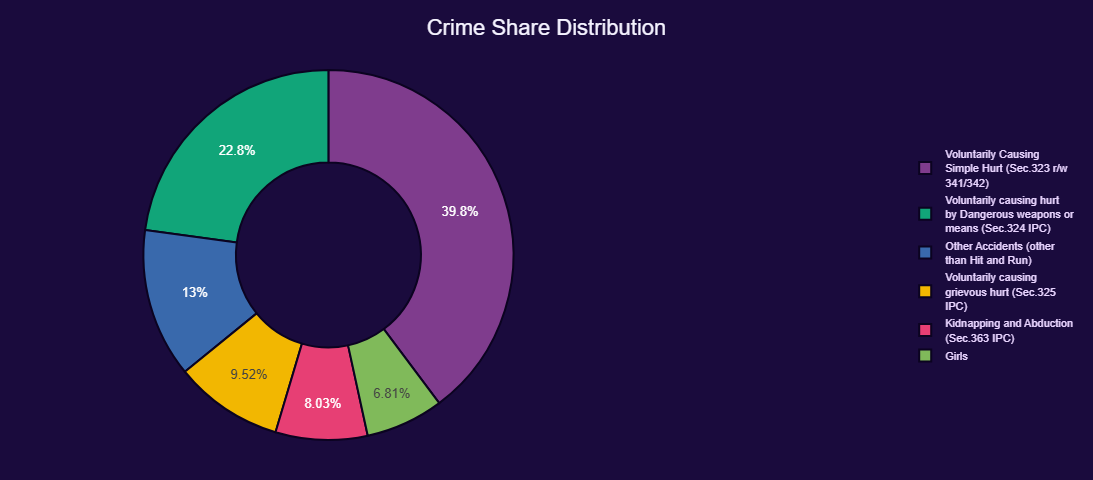

In [47]:
import textwrap
import plotly.express as px

# =========================
# STEP 1 — Aggregate Top 6
# =========================
pie_df = (
    df.groupby("Crime")["Value"]
    .sum()
    .reset_index()
    .sort_values("Value", ascending=False)
    .head(6)
)

# =========================
# STEP 2 — Clean + Wrap labels (KEY FIX)
# =========================
pie_df["Crime_clean"] = (
    pie_df["Crime"]
    .str.replace(r"^[A-Za-z]\)\s*", "", regex=True)  # remove A), B) etc
    .apply(lambda x: "<br>".join(textwrap.wrap(x, width=25)))  # wrap nicely
)

# =========================
# STEP 3 — Create Donut Chart
# =========================
fig2 = px.pie(
    pie_df,
    names="Crime_clean",
    values="Value",
    hole=0.5,
    title="Crime Share Distribution",
    color_discrete_sequence=px.colors.qualitative.Bold
)

# =========================
# STEP 4 — Styling
# =========================
fig2.update_traces(
    textinfo="percent",
    textfont_size=13,
    marker=dict(line=dict(color="#0b0320", width=2))
)

fig2.update_layout(
    height=480,
    margin=dict(l=40, r=200, t=70, b=40),  # more space for legend
    
    title=dict(font=dict(size=22)),
    
    legend=dict(
        x=1.05,
        y=0.5,
        font=dict(size=11)
    )
)

# =========================
# STEP 5 — Resize Pie
# =========================
fig2.update_traces(domain=dict(x=[0, 0.7], y=[0, 1]))

# =========================
# STEP 6 — Show
# =========================
fig2.show()

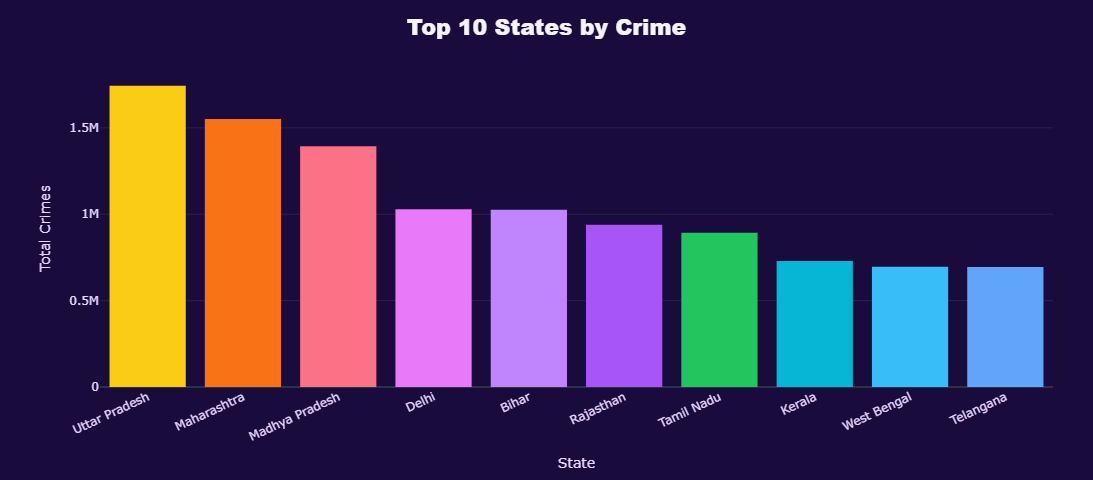

In [10]:
fig3.update_layout(
    template="plotly_dark",
    paper_bgcolor="#1a0b3d",
    plot_bgcolor="#1a0b3d",

    title=dict(
        text="Top 10 States by Crime",
        x=0.5,
        xanchor="center",
        font=dict(
            size=22,
            color="#f5f3ff",
            family="Arial Black"
        )
    ),

    height=480,
    margin=dict(l=120, r=40, t=70, b=40),

    coloraxis=dict(   # 👈 THIS IS THE FIX
        colorscale=[
            "#f97316",
            "#facc15",
            "#22c55e",
            "#38bdf8"
        ]
    ),
    coloraxis_showscale=False,

    xaxis=dict(
        showgrid=True,
        gridcolor="rgba(255,255,255,0.08)",
        title_font=dict(color="#e9d5ff"),
        tickfont=dict(color="#e9d5ff")
    ),
    yaxis=dict(
        showgrid=False,
        title_font=dict(color="#e9d5ff"),
        tickfont=dict(color="#e9d5ff")
    ),

    font=dict(color="#e9d5ff")
)

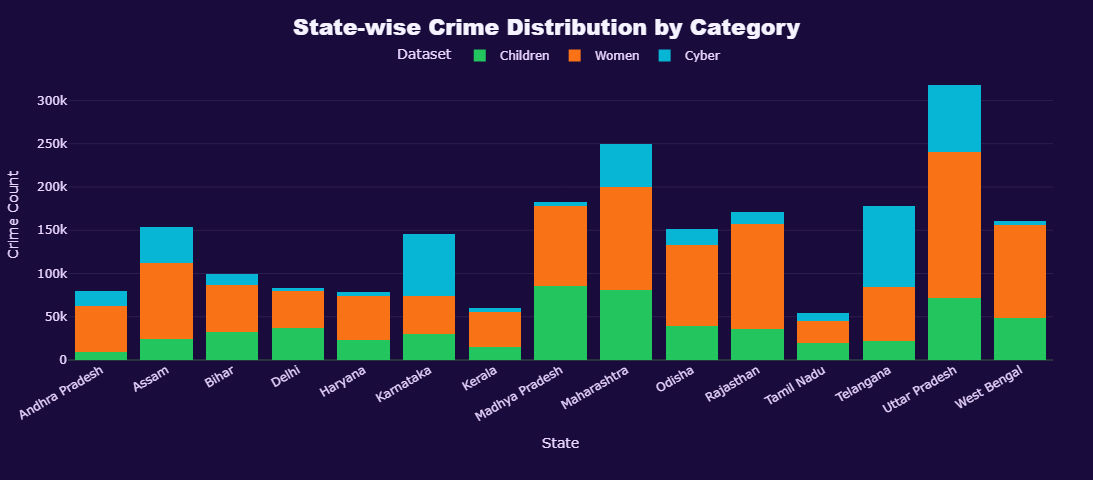

In [13]:
# --- DATA PREP ---
state_df = (
    dff[dff["Dataset"] != "IPC"]   # ❌ remove IPC
    .groupby(["State", "Dataset"])["Value"]
    .sum()
    .reset_index()
)

# Optional: limit to top 15 states for clarity
top_states = (
    state_df.groupby("State")["Value"]
    .sum()
    .nlargest(15)
    .index
)

state_df = state_df[state_df["State"].isin(top_states)]

# --- CATEGORY ORDER ---
category_order = ["Children", "Women", "Cyber"]

# --- PLOT ---
fig4 = px.bar(
    state_df,
    x="State",
    y="Value",
    color="Dataset",
    title="State-wise Crime Distribution by Category",
    category_orders={"Dataset": category_order},

    color_discrete_map={
        "Children": "#22c55e",  # green
        "Women": "#f97316",     # orange
        "Cyber": "#06b6d4"      # cyan
    }
)

# --- LAYOUT ---
fig4.update_layout(
    template="plotly_dark",
    paper_bgcolor="#1a0b3d",
    plot_bgcolor="#1a0b3d",

    barmode="stack",

    title=dict(
        x=0.5,
        xanchor="center",
        font=dict(
            size=22,
            color="#f5f3ff",
            family="Arial Black"
        )
    ),

    height=480,
    margin=dict(l=60, r=40, t=70, b=120),

    xaxis=dict(
        title="State",
        tickangle=-30,
        showgrid=False,
        tickfont=dict(color="#e9d5ff"),
        title_font=dict(color="#e9d5ff")
    ),

    yaxis=dict(
        title="Crime Count",
        showgrid=True,
        gridcolor="rgba(255,255,255,0.08)",
        tickfont=dict(color="#e9d5ff"),
        title_font=dict(color="#e9d5ff")
    ),

    legend=dict(
        orientation="h",
        y=1.1,
        x=0.5,
        xanchor="center",
        font=dict(size=12)
    ),

    font=dict(color="#e9d5ff")
)

# --- CLEAN BARS ---
fig4.update_traces(marker_line_width=0)

fig4.show()

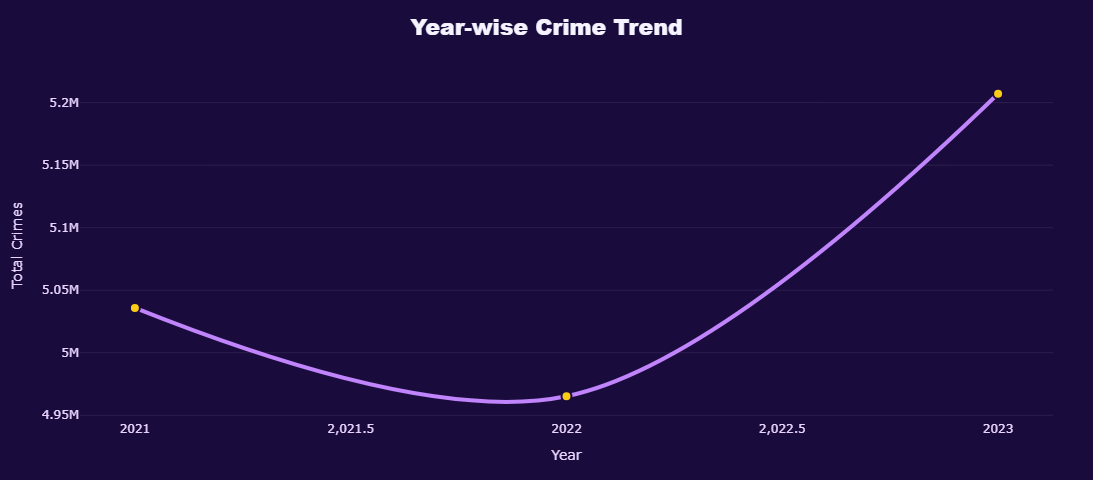

In [15]:
# --- DATA PREP ---
trend_df = (
    dff.groupby("Year")["Value"]
    .sum()
    .reset_index()
)

# --- PLOT ---
fig5 = px.line(
    trend_df,
    x="Year",
    y="Value",
    markers=True,
    title="Year-wise Crime Trend"
)

# --- STYLE ---
fig5.update_traces(
    line=dict(
        color="#c084fc",   # bright violet (theme match)
        width=4,
        shape="spline"
    ),
    marker=dict(
        size=10,
        color="#facc15",   # yellow highlight
        line=dict(width=2, color="#1a0b3d")
    )
)

# --- LAYOUT ---
fig5.update_layout(
    template="plotly_dark",
    paper_bgcolor="#1a0b3d",
    plot_bgcolor="#1a0b3d",

    title=dict(
        x=0.5,
        xanchor="center",
        font=dict(
            size=22,
            color="#f5f3ff",
            family="Arial Black"
        )
    ),

    height=480,
    margin=dict(l=80, r=40, t=70, b=60),

    xaxis=dict(
        title="Year",
        showgrid=False,
        tickfont=dict(color="#e9d5ff"),
        title_font=dict(color="#e9d5ff")
    ),

    yaxis=dict(
        title="Total Crimes",
        showgrid=True,
        gridcolor="rgba(255,255,255,0.08)",
        tickfont=dict(color="#e9d5ff"),
        title_font=dict(color="#e9d5ff")
    ),

    font=dict(color="#e9d5ff")
)

fig5.show()

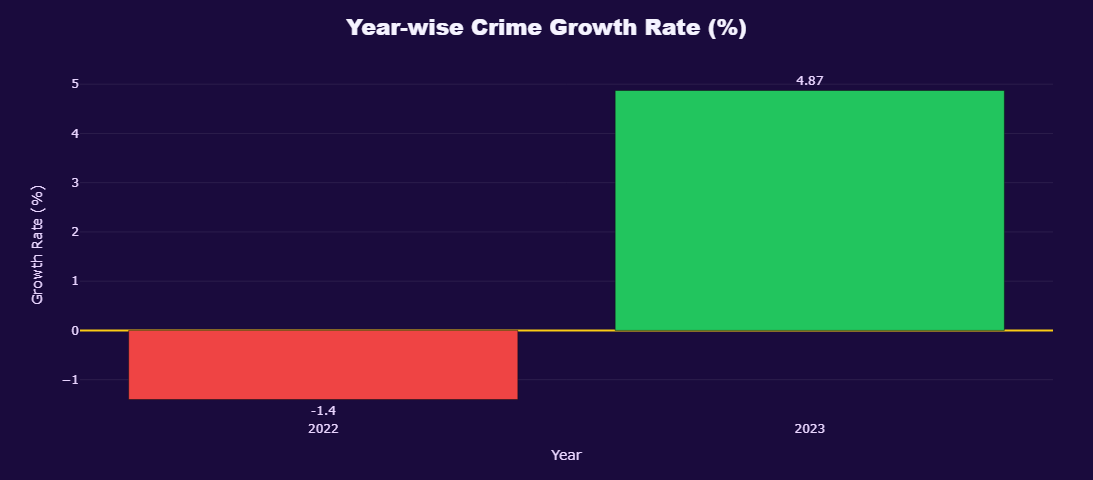

In [28]:
df_year = (
    dff.groupby("Year")["Value"]
    .sum()
    .reset_index()
    .sort_values("Year")
)

df_year["Growth_Rate"] = df_year["Value"].pct_change() * 100

# Remove first NaN (no previous year)
df_year = df_year.dropna()

# Convert Year to string (IMPORTANT for clean axis)
df_year["Year"] = df_year["Year"].astype(str)

fig6 = px.bar(
    df_year,
    x="Year",
    y="Growth_Rate",
    text=df_year["Growth_Rate"].round(2),
    title="Year-wise Crime Growth Rate (%)"
)

fig6.update_traces(
    marker_color=[
        "#ef4444" if val < 0 else "#22c55e"
        for val in df_year["Growth_Rate"]
    ],   # green (growth meaning)
    textposition="outside"
)

fig6.update_layout(
    template="plotly_dark",
    paper_bgcolor="#1a0b3d",
    plot_bgcolor="#1a0b3d",

    title=dict(
        x=0.5,
        xanchor="center",
        font=dict(
            size=22,
            color="#f5f3ff",
            family="Arial Black"
        )
    ),

    height=480,
    margin=dict(l=80, r=40, t=70, b=60),

    xaxis=dict(
        title="Year",
        showgrid=False,
        tickfont=dict(color="#e9d5ff"),
        title_font=dict(color="#e9d5ff")
    ),

    yaxis=dict(
        title="Growth Rate (%)",
        showgrid=True,
        gridcolor="rgba(255,255,255,0.08)",
        tickfont=dict(color="#e9d5ff"),
        title_font=dict(color="#e9d5ff"),

        zeroline=True,
        zerolinecolor="#facc15",
        zerolinewidth=2
    ),

    font=dict(color="#e9d5ff")
)

fig6.show()

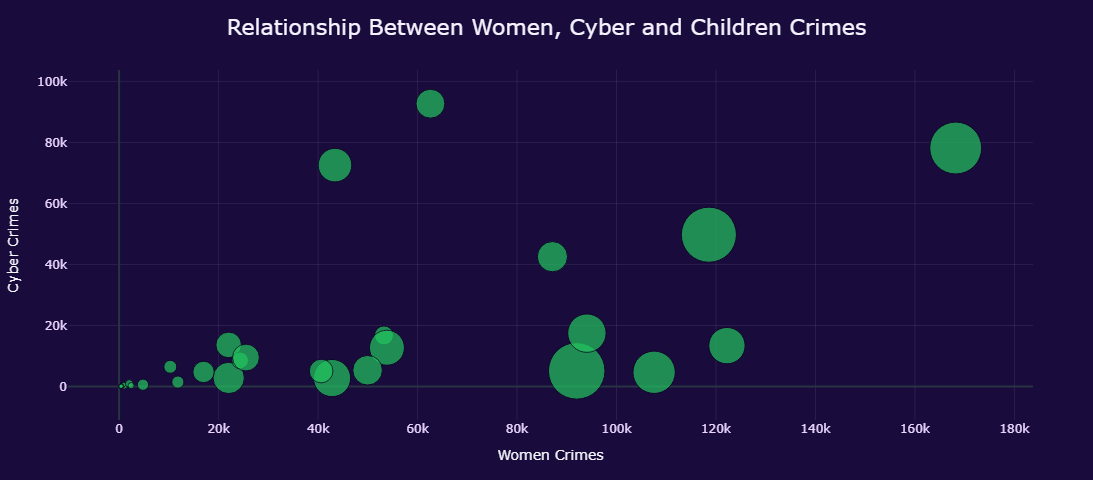

In [49]:
# =========================
# FIG 8 — Relationship Analysis (Scatter Plot)
# =========================

scatter_df = (
    dff.groupby(["State", "Dataset"])["Value"]
    .sum()
    .reset_index()
    .pivot(index="State", columns="Dataset", values="Value")
    .fillna(0)
    .reset_index()
)

fig8 = px.scatter(
    scatter_df,
    x="Women",
    y="Cyber",
    size="Children",
    hover_name="State",
    title="Relationship Between Women, Cyber and Children Crimes",
    size_max=40
)

fig8.update_traces(
    marker=dict(
        color="#22c55e",
        opacity=0.7,
        line=dict(width=1, color="#0b0320")
    )
)

fig8.update_layout(
    template="plotly_dark",
    paper_bgcolor="#1a0b3d",
    plot_bgcolor="#1a0b3d",

    title=dict(
        x=0.5,
        font=dict(size=22, color="#f5f3ff")
    ),

    xaxis=dict(
        title="Women Crimes",
        showgrid=True,
        gridcolor="rgba(255,255,255,0.08)",
        tickfont=dict(color="#e9d5ff")
    ),

    yaxis=dict(
        title="Cyber Crimes",
        showgrid=True,
        gridcolor="rgba(255,255,255,0.08)",
        tickfont=dict(color="#e9d5ff")
    ),

    height=480,
    margin=dict(l=60, r=60, t=70, b=60)
)

fig8.show()

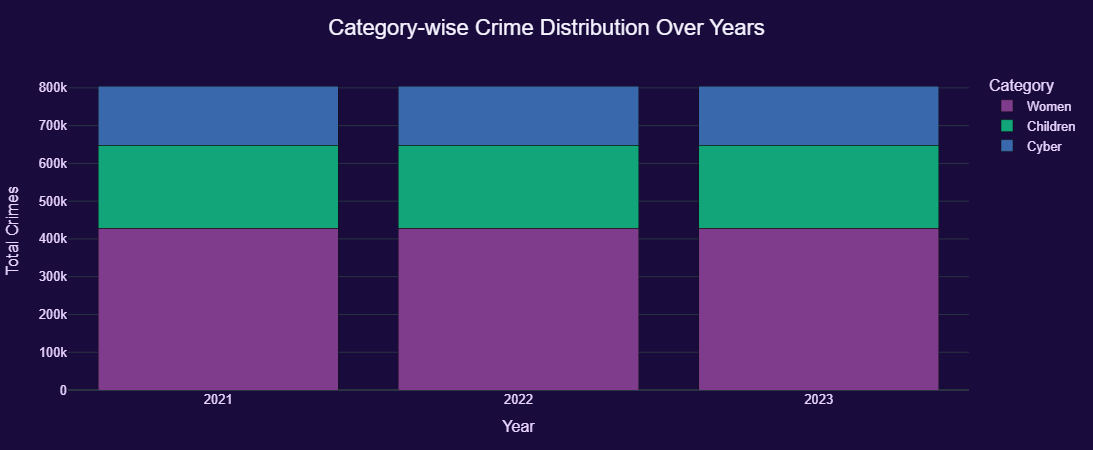

In [57]:
stack_df = (
    dff[dff["Dataset"] != "IPC"]
    .groupby(["Year", "Dataset"])["Value"]
    .sum()
    .reset_index()
)

fig_new = px.bar(
    stack_df,
    x="Year",
    y="Value",
    color="Dataset",
    title="Category-wise Crime Distribution Over Years",
    barmode="stack",
    color_discrete_sequence=px.colors.qualitative.Bold,
    category_orders={"Dataset": ["Women", "Children", "Cyber"]}
)

fig_new.update_layout(
    height=450,
    xaxis=dict(title="Year"),
    yaxis=dict(title="Total Crimes"),
    legend=dict(title="Category"),
    margin=dict(l=60, r=60, t=70, b=60)
)

fig_new.show()

In [58]:
import pandas as pd

stat_df = dff[dff["Dataset"].isin(["Women", "Children", "Cyber"])]

skew_kurt = stat_df.groupby("Dataset")["Value"].agg(
    Skewness="skew",
    Kurtosis="kurt"
).reset_index()

print(skew_kurt)

    Dataset   Skewness    Kurtosis
0  Children   9.145288  106.271133
1     Cyber  11.141665  139.555617
2     Women   8.788802   97.313083


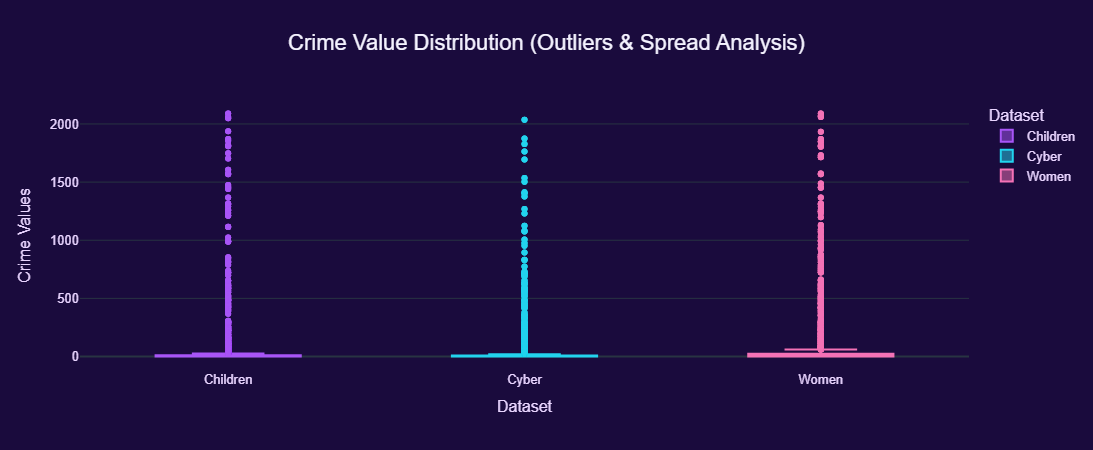

In [66]:
fig_stat2 = px.box(
    stat_df,
    x="Dataset",
    y="Value",
    color="Dataset",
    title="Crime Value Distribution (Outliers & Spread Analysis)"
)

fig_stat2.update_layout(
    height=450,
    yaxis_title="Crime Values"
)

fig_stat2.show()

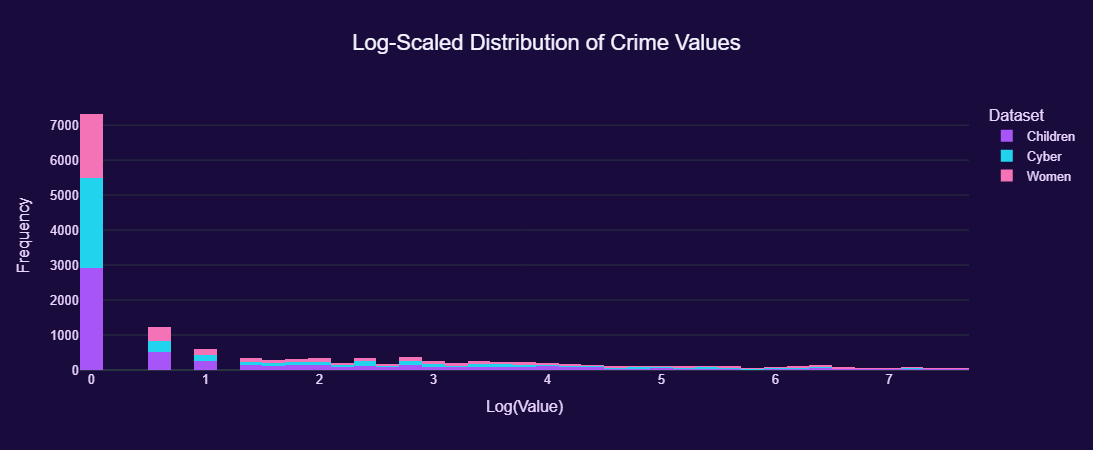

In [78]:
import numpy as np

stat_df["Log_Value"] = np.log1p(stat_df["Value"])

fig_stat3 = px.histogram(
    stat_df,
    x="Log_Value",
    color="Dataset",
    nbins=50,
    title="Log-Scaled Distribution of Crime Values"
)

fig_stat3.update_layout(
    height=450,
    xaxis_title="Log(Value)",
    yaxis_title="Frequency"
)

fig_stat3.show()

In [79]:
# Create feature dataset for correlation

df_feat = df.copy()

# Ensure sorting
df_feat = df_feat.sort_values(["State", "Dataset", "Year"])

# Yearly Change
df_feat["Yearly_Change"] = df_feat.groupby(["State", "Dataset"])["Value"].diff()

# Growth Rate (%)
df_feat["Growth_Rate"] = (
    df_feat.groupby(["State", "Dataset"])["Value"]
    .pct_change() * 100
)

# Contribution % (state contribution within dataset)
df_feat["Contribution_%"] = (
    df_feat["Value"] /
    df_feat.groupby(["Dataset", "Year"])["Value"].transform("sum")
) * 100

# Drop NaN (important for correlation)
df_feat = df_feat.dropna()

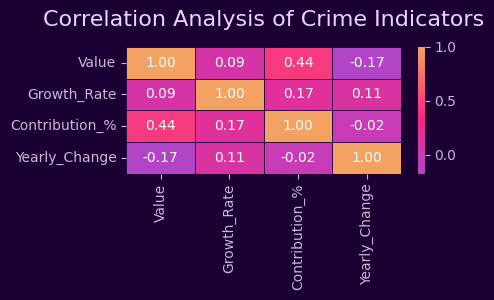

In [152]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
import panel as pn

# ================= CREATE CUSTOM COLORMAP =================
custom_cmap = LinearSegmentedColormap.from_list(
    "neon_purple_theme",
    [
        "#00f5d4",   # cyan (low)
        "#9d4edd",   # purple (mid)
        "#f72585",   # pink (high)
        "#f4a261"    # soft yellow (very high)
    ]
)

# ================= PREPARE DATA =================
cols = ["Value", "Growth_Rate", "Contribution_%", "Yearly_Change"]
corr = df_feat[cols].corr()

# ================= CREATE HEATMAP FIGURE =================
fig_heatmap, ax = plt.subplots(figsize=(4.9, 3.1), facecolor="#1a0033")

sns.heatmap(
    corr,
    cmap=custom_cmap,
    annot=True,
    fmt=".2f",
    linewidths=0.6,
    linecolor="#2a0a4a",
    cbar=True,
    center=0,
    annot_kws={"color": "white", "fontsize": 10},
    ax=ax
)

# ================= STYLING =================
ax.set_facecolor("#1a0033")

ax.set_title(
    "Correlation Analysis of Crime Indicators",
    fontsize=16,
    color="#e9d5ff",
    pad=15
)

ax.tick_params(colors="#cdb4db")

# colorbar styling
cbar = ax.collections[0].colorbar
cbar.ax.yaxis.set_tick_params(color="#cdb4db")
plt.setp(cbar.ax.get_yticklabels(), color="#cdb4db")

plt.tight_layout()

# ================= PANEL DISPLAY =================
heatmap_pane = pn.pane.Matplotlib(fig_heatmap, tight=True)

In [144]:
!pip install ipywidgets


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [82]:
import ipywidgets as widgets
from IPython.display import display

In [99]:
# -----------------------------
# 1. Year Filter
# -----------------------------
year_filter = widgets.Dropdown(
    options=["All"]+sorted(df["Year"].unique()),
    value="All",
    description='Year',
)

# -----------------------------
# 2. State Filter
# -----------------------------
state_filter = widgets.SelectMultiple(
    options=sorted(df["State"].unique()),
    description='State'
)

# -----------------------------
# 3. Crime Category Filter
# -----------------------------
category_filter = widgets.Dropdown(
    options=["All", "Women", "Cyber", "Children"],
    value="All",
    description='Category'
)

# -----------------------------
# 4. Top N Filter
# -----------------------------
topn_filter = widgets.IntSlider(
    value=10,
    min=5,
    max=20,
    step=1,
    description='Top N States'
)

# -----------------------------
# 5. Value Range Filter
# -----------------------------
value_filter = widgets.IntRangeSlider(
    value=[0, int(df["Value"].max())],
    min=0,
    max=int(df["Value"].max()),
    step=10,
    description='Value Range'
)

In [10]:
display(year_filter, state_filter, category_filter, topn_filter, value_filter)

Select(name='Year', options=['All', 2021, 2022, 2023], value='All')

MultiChoice(name='State', options=['Andhra Pradesh', ...], value=['Andhra Pradesh', ...])

Select(name='Category', options=['All', 'A. Offences under...], value='All')

IntSlider(end=20, name='Top N States', start=5, value=10)

RangeSlider(end=188492, name='Value Range', step=1, value=(0, 188492), value_end=188492)

In [101]:
def get_filtered_data():
    filtered_df = df.copy()

    # Year filter
    if year_filter.value!="All":
        filtered_df = filtered_df[filtered_df["Year"].isin(year_filter.value)]

    # State filter
    if state_filter.value:
        filtered_df = filtered_df[filtered_df["State"].isin(state_filter.value)]

    # Category filter
    if category_filter.value != "All":
        filtered_df = filtered_df[
            filtered_df["Dataset"] == category_filter.value
        ]

    # Value filter
    
    filtered_df = filtered_df[
        (filtered_df["Value"] >= value_filter.value[0]) &
        (filtered_df["Value"] <= value_filter.value[1])
    ]

    return filtered_df

In [102]:
def update_dashboard(change=None):
    filtered_df = get_filtered_data()

    # All charts use filtered_df instead of df

In [103]:
year_filter.observe(update_dashboard, names='value')
state_filter.observe(update_dashboard, names='value')
category_filter.observe(update_dashboard, names='value')
topn_filter.observe(update_dashboard, names='value')
value_filter.observe(update_dashboard, names='value')

In [9]:
# ==============================
# IMPORTS
# ==============================
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
import panel as pn

pn.extension('plotly')

# ==============================
# LOAD DATA
# ==============================
# Replace with your dataset path
df = pd.read_csv("C:/Users/Varnika Sharma/Desktop/Crime Analysis/Crime Analysis/01_Data/Final_Dataset/cleaned_crime_data.csv")

# ==============================
# PREPROCESSING
# ==============================
df_feat = df.copy()
df_feat = df_feat.sort_values(["State", "Dataset", "Year"])

# Yearly Change
df_feat["Yearly_Change"] = df_feat.groupby(["State", "Dataset"])["Value"].diff()

# Growth Rate
df_feat["Growth_Rate"] = (
    df_feat.groupby(["State", "Dataset"])["Value"].pct_change() * 100
)

# Contribution %
df_feat["Contribution_%"] = (
    df_feat["Value"] /
    df_feat.groupby(["Dataset", "Year"])["Value"].transform("sum")
) * 100

df_feat = df_feat.dropna()

# ==============================
# FILTER WIDGETS
# ==============================
dataset_filter = pn.widgets.MultiChoice(
    name='Dataset',
    options=list(df["Dataset"].unique()),
    value=list(df["Dataset"].unique())
)

state_filter = pn.widgets.MultiChoice(
    name='State',
    options=list(df["State"].unique()),
    value=list(df["State"].unique())[:5]
)

year_slider = pn.widgets.IntSlider(
    name='Year',
    start=int(df["Year"].min()),
    end=int(df["Year"].max()),
    value=int(df["Year"].max())
)

topn_slider = pn.widgets.IntSlider(
    name='Top N States',
    start=5,
    end=20,
    value=10
)

value_range = pn.widgets.RangeSlider(
    name='Value Range',
    start=0,
    end=int(df["Value"].max()),
    value=(0, int(df["Value"].max()))
)

# ==============================
# FILTER FUNCTION
# ==============================
def get_filtered_df():
    dff = df.copy()

    dff = dff[dff["Dataset"].isin(dataset_filter.value)]
    dff = dff[dff["State"].isin(state_filter.value)]
    dff = dff[dff["Year"] == year_slider.value]

    dff = dff[
        (dff["Value"] >= value_range.value[0]) &
        (dff["Value"] <= value_range.value[1])
    ]

    return dff

# ==============================
# CHART 1: SCATTER
# ==============================
def scatter_plot():
    dff = get_filtered_df()

    scatter_df = (
        dff.groupby(["State", "Dataset"])["Value"]
        .sum()
        .reset_index()
        .pivot(index="State", columns="Dataset", values="Value")
        .fillna(0)
        .reset_index()
    )

    fig = px.scatter(
        scatter_df,
        x="Women",
        y="Cyber",
        size="Children",
        hover_name="State",
        title="Relationship Between Women, Cyber and Children Crimes"
    )

    fig.update_layout(template="plotly_dark")
    return fig

# ==============================
# CHART 2: STACKED BAR
# ==============================
def stacked_bar():
    dff = df[df["Dataset"].isin(["Women", "Children", "Cyber"])]

    stack_df = (
        dff.groupby(["Year", "Dataset"])["Value"]
        .sum()
        .reset_index()
    )

    fig = px.bar(
        stack_df,
        x="Year",
        y="Value",
        color="Dataset",
        barmode="stack",
        title="Category-wise Crime Distribution Over Years"
    )

    fig.update_layout(template="plotly_dark")
    return fig

# ==============================
# CHART 3: BOX PLOT
# ==============================
def box_plot():
    stat_df = df[df["Dataset"].isin(["Women", "Children", "Cyber"])]

    fig = px.box(
        stat_df,
        x="Dataset",
        y="Value",
        color="Dataset",
        title="Crime Value Distribution (Outliers & Spread)"
    )

    fig.update_layout(template="plotly_dark")
    return fig

# ==============================
# CHART 4: HISTOGRAM (LOG SCALE)
# ==============================
def histogram():
    stat_df = df[df["Dataset"].isin(["Women", "Children", "Cyber"])].copy()
    stat_df["Log_Value"] = np.log1p(stat_df["Value"])

    fig = px.histogram(
        stat_df,
        x="Log_Value",
        color="Dataset",
        nbins=50,
        title="Log-Scaled Distribution of Crime Values"
    )

    fig.update_layout(template="plotly_dark")
    return fig

# ==============================
# CHART 5: HEATMAP
# ==============================
def heatmap():
    cols = ["Value", "Growth_Rate", "Contribution_%", "Yearly_Change"]
    corr = df_feat[cols].corr()

    plt.figure(figsize=(8, 5))
    sns.heatmap(corr, annot=True, cmap="coolwarm")
    plt.title("Correlation Analysis of Crime Indicators")

    return plt.gcf()

# ==============================
# KPI CARDS
# ==============================
def kpi_cards():
    dff = get_filtered_df()

    total = int(dff["Value"].sum())
    avg = int(dff["Value"].mean())
    max_val = int(dff["Value"].max())

    return pn.Row(
        pn.pane.Markdown(f"### Total Crimes\n## {total}"),
        pn.pane.Markdown(f"### Average Crimes\n## {avg}"),
        pn.pane.Markdown(f"### Max Crimes\n## {max_val}")
    )

# ==============================
# DASHBOARD LAYOUT
# ==============================
dashboard = pn.Column(

    "# 🚨 Crime Analysis Dashboard",

    pn.Row(dataset_filter, state_filter),
    pn.Row(year_slider, topn_slider, value_range),

    kpi_cards,

    pn.Row(
        pn.pane.Plotly(scatter_plot),
        pn.pane.Plotly(stacked_bar)
    ),

    pn.Row(
        pn.pane.Plotly(box_plot),
        pn.pane.Plotly(histogram)
    ),

    pn.Row(
        pn.pane.Matplotlib(heatmap)
    )
)

# ==============================
# SERVE DASHBOARD
# ==============================
dashboard.servable()

ValueError: Plotly pane does not support objects of type 'function'.